 UE23CS352A : Machine Learning Mini-Project



Project : Human Activity Recognition

Team member 1 Name: Harsha Madev Hegde


Team member 1 SRN: PES2UG23CS212


Team member 2 Name: Gudihalli Kiran


Team member 2 SRN: PES2UG23CS207

This first cell handles all the necessary setup. We import essential libraries like TensorFlow for building the model, Pandas for data handling, and Matplotlib/Seaborn for creating visualizations. We also set a global random seed to ensure that our experiment is reproducible, meaning we will get the exact same results every time we run the code.

In [45]:
import tensorflow as tf
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# --- Set random seeds for reproducible results ---
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

This cell prepares our dataset. It first checks if the train.csv and test.csv files have already been uploaded to the data/ folder. If they haven't, it will prompt us to upload them from our local machine. This ensures the notebook has the necessary data before proceeding.

In [23]:
import os

# Define the expected file paths
train_file_path = 'data/train.csv'
test_file_path = 'data/test.csv'

# Check if both files exist in the 'data' folder
if os.path.exists(train_file_path) and os.path.exists(test_file_path):
  print("✅ Success: train.csv and test.csv found in the 'data' folder.")
else:
  print("❌ Error: One or both CSV files were not found in the 'data' folder.")
  print("Please make sure you have uploaded both train.csv and test.csv correctly.")

✅ Success: train.csv and test.csv found in the 'data' folder.


This cell defines the load_har_dataset function. This function is responsible for reading the CSV files, separating the motion features from the activity labels, converting the text labels into a numerical format (one-hot encoding), and reshaping the data into the 3D format required by the LSTM model.

In [25]:
def load_har_dataset(data_path='data/'):
    """
    Loads the UCI-HAR dataset and preprocesses it for the LSTM model.
    """
    print("Loading data from CSV files...")
    train_file = os.path.join(data_path, 'train.csv')
    test_file = os.path.join(data_path, 'test.csv')

    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)

    X_train = train_df.drop('Activity', axis=1).values
    y_train_labels = train_df['Activity'].values
    X_test = test_df.drop('Activity', axis=1).values
    y_test_labels = test_df['Activity'].values

    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train_labels)
    y_test_encoded = label_encoder.transform(y_test_labels)

    num_classes = len(label_encoder.classes_)
    y_train = to_categorical(y_train_encoded, num_classes)
    y_test = to_categorical(y_test_encoded, num_classes)

    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

    print("Data loading and preprocessing complete.")
    return X_train, y_train, X_test, y_test

Before training, it's important to understand our data. This cell creates a bar chart to visualize the distribution of the six activities in the training set. This helps us confirm that the dataset is well-balanced, meaning we have a similar number of examples for each activity, which is ideal for training a robust model.

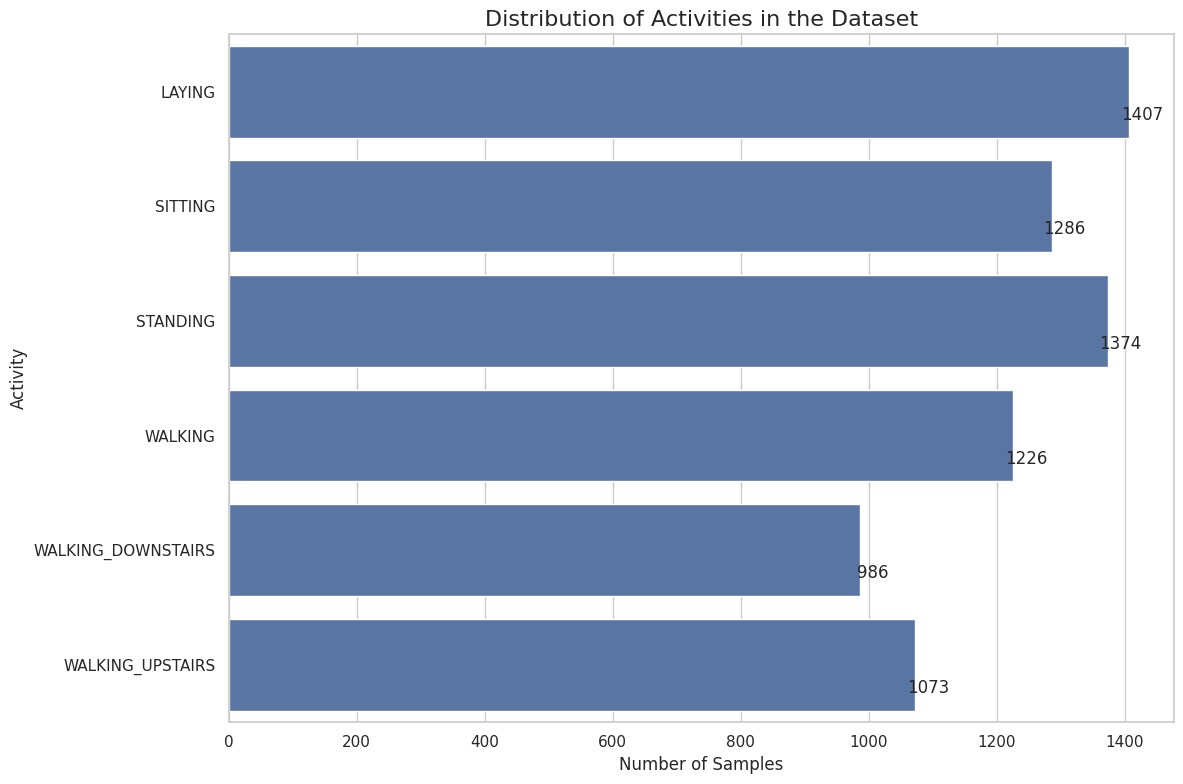

In [44]:
# Load the training data to visualize it
train_df_vis = pd.read_csv('data/train.csv')

# Set the style for the plot
sns.set(style="whitegrid")

# Create a figure to draw on
plt.figure(figsize=(12, 8))

# Create the bar plot, ordering the activities alphabetically
ax = sns.countplot(y='Activity', data=train_df_vis, order=sorted(train_df_vis['Activity'].unique()))

# Add a title and labels for clarity
ax.set_title('Distribution of Activities in the Dataset', fontsize=16)
ax.set_xlabel('Number of Samples', fontsize=12)
ax.set_ylabel('Activity', fontsize=12)

# Add the exact count at the end of each bar
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 20, p.get_y() + p.get_height()/2. + 0.2,
             f'{int(width)}',
             ha='center', va='center')

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

Here, we define the blueprint for our neural network's "brain." The build_lstm_model function creates a Sequential model consisting of an LSTM layer to process the time-series data, a Dropout layer to prevent overfitting, and two Dense layers for final classification.

In [26]:
def build_lstm_model(input_shape, num_classes):
    """
    Builds the LSTM model architecture.
    """
    model = Sequential([
        LSTM(100, input_shape=input_shape),
        Dropout(0.5),
        Dense(100, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

This is the main experimental cell. It loads the preprocessed data and then runs the training process twice: once with the Adam optimizer and once with the SGD optimizer. It trains each model for 5 epochs, evaluates its final performance on the unseen test set, and saves the best-performing model (Adam) to a file named har_adam_model.h5.

In [27]:
# Load the data
X_train, y_train, X_test, y_test = load_har_dataset()

# Get model parameters from data shape
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = y_train.shape[1]

# Define optimizers and history log
optimizers_to_compare = ['adam', 'sgd']
training_histories = {}

# Loop to train with each optimizer
for optimizer_name in optimizers_to_compare:
    print(f"\n--- Training with Optimizer: {optimizer_name.upper()} ---")

    model = build_lstm_model(input_shape=input_shape, num_classes=num_classes)

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=0.0001)
    else:
        optimizer = SGD()

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=64,
        validation_data=(X_test, y_test),
        verbose=1
    )
    training_histories[optimizer_name] = history

    if optimizer_name == 'adam':
        model.save('har_adam_model.h5')
        print("\nAdam model saved as har_adam_model.h5")

    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    train_accuracy = history.history['accuracy'][-1]
    train_loss = history.history['loss'][-1]

    print(f"\n--- Final Results for {optimizer_name.upper()} ---")
    print(f"Final Training Accuracy: {train_accuracy*100:.2f}%")
    print(f"Final Training Error (Loss): {train_loss:.4f}")
    print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")
    print(f"Final Test Error (Loss): {test_loss:.4f}")

Loading data from CSV files...
Data loading and preprocessing complete.

--- Training with Optimizer: ADAM ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3034 - loss: 1.6361 - val_accuracy: 0.7526 - val_loss: 1.0828
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6120 - loss: 1.0414 - val_accuracy: 0.8239 - val_loss: 0.6956
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7760 - loss: 0.6959 - val_accuracy: 0.8711 - val_loss: 0.4948
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8332 - loss: 0.5071 - val_accuracy: 0.8901 - val_loss: 0.3855
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8690 - loss: 0.3981 - val_accuracy: 0.9053 - val_loss: 0.3219



Adam model saved as har_adam_model.h5

--- Final Results for ADAM ---
Final Training Accuracy: 87.46%
Final Training Error (Loss): 0.3760
Final Test Accuracy: 90.53%
Final Test Error (Loss): 0.3219

--- Training with Optimizer: SGD ---
Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2698 - loss: 1.7155 - val_accuracy: 0.3488 - val_loss: 1.4405
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4238 - loss: 1.3728 - val_accuracy: 0.5110 - val_loss: 1.1698
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5328 - loss: 1.1388 - val_accuracy: 0.6766 - val_loss: 1.0043
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6076 - loss: 0.9991 - val_accuracy: 0.7428 - val_loss: 0.8625
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6741 - loss: 0.8687 - val_accuracy: 0.7838 - val_loss: 0.7297

--- Final Results for SGD ---
Final Training Accuracy: 69.33%
Final Training Error (Loss): 0.8319
Final Test Accuracy: 78.38%
F

After the training is complete, this cell generates a plot of the learning curves. The graph compares the training and validation accuracy for both the Adam and SGD models over the 5 epochs. This visualization provides a clear, immediate understanding of which optimizer performed better and how they learned over time.

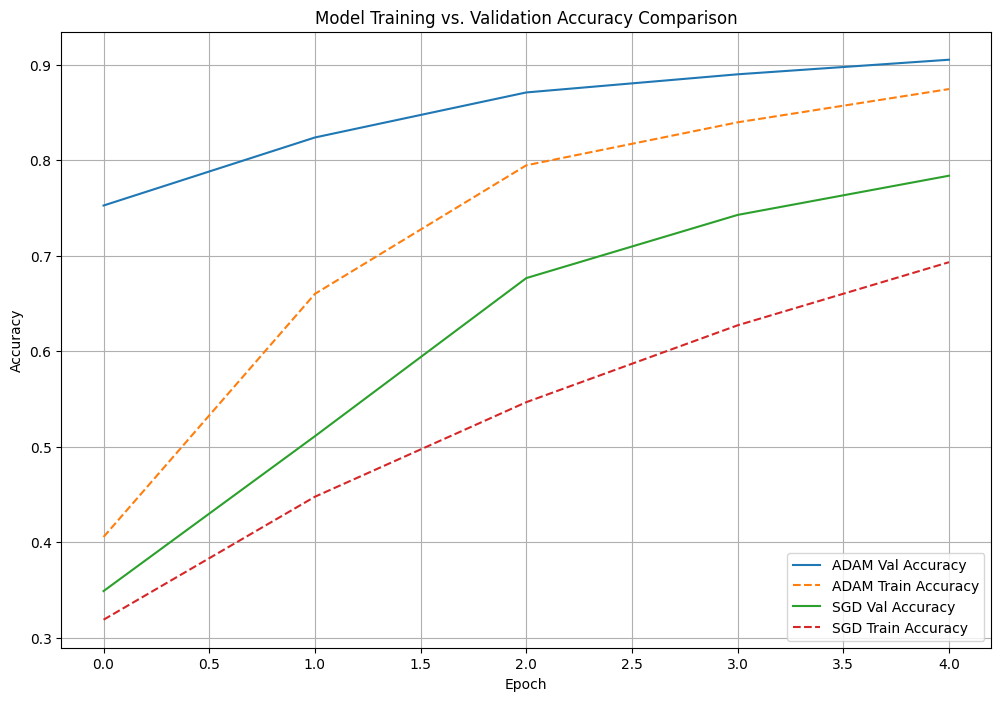

In [28]:
plt.figure(figsize=(12, 8))
for optimizer_name, history in training_histories.items():
    plt.plot(history.history['val_accuracy'], linestyle='-', label=f'{optimizer_name.upper()} Val Accuracy')
    plt.plot(history.history['accuracy'], linestyle='--', label=f'{optimizer_name.upper()} Train Accuracy')

plt.title('Model Training vs. Validation Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

This final cell demonstrates the practical application of our trained model. It loads the saved har_adam_model.h5 file and prompts the user to paste a new, unseen row of sensor data. The model then processes this input and makes a live prediction, showing the probability for each of the six activities and concluding with its final guess.

In [40]:
# Load the saved model
try:
    print("\nLoading the trained Adam model for prediction...")
    model = load_model('har_adam_model.h5')
    print("Model loaded successfully.")
except Exception as e:
    print(f"\nError: Could not load 'har_adam_model.h5'.")
    print(f"Please run the training cell first to generate the model file.")

# Get manual input
print("\n--- Manual Input for Prediction ---")
print("Please open 'data/test.csv', copy one data row (excluding the activity label), and paste it below.")
pasted_data = input("Paste the 562 comma-separated values here and press Enter:\n")

# Process and predict
try:
    input_features = [float(x) for x in pasted_data.split(',')]
    if len(input_features) != 562:
        print(f"\nError: Pasted {len(input_features)} values, but the model requires exactly 562.")
    else:
        sample_data = np.array(input_features)
        sample_data = sample_data.reshape(1, 1, -1)
        probabilities = model.predict(sample_data)[0]
        predicted_class_index = np.argmax(probabilities)
        class_labels = [
            'LAYING',
            'SITTING',
            'STANDING',
            'WALKING',
            'WALKING_DOWNSTAIRS',
            'WALKING_UPSTAIRS'
        ]
        predicted_activity = class_labels[predicted_class_index]

        print("\n--- Prediction Results ---")
        print("\nModel Output (Probabilities):")
        for i, label in enumerate(class_labels):
            print(f"- {label}: {probabilities[i]*100:.2f}%")
        print(f"\nConclusion: The model predicts the activity is: {predicted_activity}")

except ValueError:
    print("\nError: Data was not a comma-separated list of numbers.")


Loading the trained Adam model for prediction...
Model loaded successfully.

--- Manual Input for Prediction ---
Please open 'data/test.csv', copy one data row (excluding the activity label), and paste it below.
Paste the 562 comma-separated values here and press Enter:
0.18485338,-0.041543376,-0.11706283,-0.15218339,0.31154095,-0.22840606,-0.24034148,0.28515894,-0.25414451,0.10927308,-0.10485734,-0.44509163,-0.006500721,-0.177175,0.12651247,-0.010872835,-0.63772144,-0.66774539,-0.73050537,-0.45641513,0.060821055,-0.30349457,0.24448517,0.31800409,0.22390849,-0.52747782,0.42783213,-0.2616373,0.2168486,-0.33105636,0.14629847,0.35195621,-0.2987704,-0.19232549,0.030261064,0.44473123,-0.40795149,-0.40888514,-0.48497017,0.52990962,0.92631139,-0.27646331,-0.11941303,-0.98042196,-0.94158314,-0.96321026,-0.98254468,-0.94098053,-0.9612166,0.86051029,-0.27849081,-0.11885834,0.93752747,-0.26156814,-0.1241203,-0.037603704,0.80277483,-0.87097098,-0.96902103,-0.98611497,-0.9443519,-0.95970746,-0.473